# 🎯 1. Indexing Fundamentals

Ο **πιο υποτιμημένος** παράγοντας στο RAG είναι το indexing. Η αρχιτεκτονική «retriever + LLM» μοιάζει εντυπωσιακή, αλλά αν τα chunks σου είναι κακά κομμένα, καμία fancy τεχνική δεν θα σε σώσει.

Σε αυτό το notebook θα δούμε:

1. **Loading** — πώς φέρνουμε docs από διαφορετικές πηγές
2. **Chunking** — η τέχνη του «πόσο μεγάλο/μικρό»
3. **Embeddings** — από τι αποτελούνται και πώς συγκρίνονται
4. **Vector stores** — Chroma και FAISS στην πράξη
5. **Metadata** — γιατί είναι sneakily critical

In [13]:
import os
from pathlib import Path
from dotenv import load_dotenv
 
# Φορτώνουμε τα API keys από το .env (βρίσκεται στο root του project)
_env_path = Path(".env")
load_dotenv(dotenv_path=_env_path, override=False)
 
# Αν δεν βρεθεί το key (πχ σε Colab), ζητάμε manually
# if not os.environ.get("OPENAI_API_KEY"):
#     import getpass
#     os.environ["OPENAI_API_KEY"] = getpass.getpass("OpenAI API key: ")
 
LLM_MODEL   = "gpt-4o-mini"
EMBED_MODEL = "text-embedding-3-small"

## 1.1 Documents: η βασική μονάδα

Στο LangChain όλα τα κείμενα τυλίγονται σε ένα `Document` object με δύο πεδία:

* `page_content` — το ίδιο το κείμενο (string)
* `metadata` — λεξικό με ό,τι έξτρα πληροφορία θέλουμε (πηγή, ημ/νία, author...)

Το metadata είναι κρίσιμο για **filtering** στο retrieval (θα δούμε στο notebook 04).

In [14]:
from langchain_core.documents import Document
 
# The Document is the fundamental unit in LangChain's RAG ecosystem
doc = Document(
    page_content=(
        "RAG is an architectural pattern that grounds LLM answers in retrieved evidence. "
        "Before asking the LLM to answer, the system retrieves relevant chunks from an "
        "external corpus and injects them into the prompt as context."
    ),
    metadata={"source": "Datanous.ai_textbook.pdf", "chapter": "2", "page": 18},
)
 
print("page_content:", doc.page_content[:80], "...")
print("metadata    :", doc.metadata)
print("type        :", type(doc))

page_content: RAG is an architectural pattern that grounds LLM answers in retrieved evidence.  ...
metadata    : {'source': 'Datanous.ai_textbook.pdf', 'chapter': '2', 'page': 18}
type        : <class 'langchain_core.documents.base.Document'>


## 1.2 Loaders — από κάθε πηγή σε `Document`

Το LangChain διαθέτει **εκατοντάδες** loaders. Δείτε τα 3 πιο συχνά.

### 1.2.1 TextLoader — απλό αρχείο κειμένου

In [15]:
from pathlib import Path
 
# Create a demo knowledge base file about Datanous.ai
Path("datanous_overview.txt").write_text(
    "Datanous.ai — Company Overview\n\n"
    "Datanous.ai is an AI services company founded in 2021 and headquartered in Athens, Greece, "
    "with offices in London and Amsterdam. The company specialises in the design, development, "
    "and deployment of enterprise-grade AI systems, with a focus on Retrieval-Augmented Generation, "
    "large language model integration, and AI governance.\n\n"
    "Products:\n"
    "Datanous Insight: a RAG-powered knowledge management platform that indexes enterprise documents "
    "and answers staff queries through a natural language interface with source citations.\n"
    "Datanous Search: a hybrid search platform combining BM25 and dense semantic retrieval with "
    "cross-encoder reranking for high-precision document retrieval.\n"
    "Datanous Guard: an AI governance layer enforcing factual grounding, prompt injection detection, "
    "PII redaction, and tenant-level access control.\n"
    "Datanous Embed: a managed embeddings API supporting text-embedding-3-small and "
    "text-embedding-3-large with Redis caching.",
    encoding="utf-8",
)
print("Created datanous_overview.txt")

Created datanous_overview.txt


### 1.2.2 WebBaseLoader — από URL

In [16]:
from langchain_community.document_loaders import WebBaseLoader
from langchain_core.documents import Document

loader = WebBaseLoader("https://en.wikipedia.org/wiki/Embedding_(machine_learning)")
docs = loader.load()

print(f"Number of docs: {len(docs)}")

first_doc = docs[0]
print(f"Source: {first_doc.metadata.get('source')}")
print(f"Title: {first_doc.metadata.get('title')}")
print(f"Content: {first_doc.page_content[:100]}...")

Number of docs: 1
Source: https://en.wikipedia.org/wiki/Embedding_(machine_learning)
Title: Embedding (machine learning) - Wikipedia
Content: 



Embedding (machine learning) - Wikipedia


























Jump to content







Main m...


In [17]:
# For this demo, we simulate the result:
simulated_web_doc = Document(
    page_content=(
        "LangChain is a framework for developing applications powered by language models. "
        "It provides tools for chaining components, managing prompts, and integrating "
        "external data sources into LLM pipelines, including RAG architectures."
    ),
    metadata={
        "source": "https://docs.langchain.com",
        "title": "LangChain Introduction",
    },
)
 
print("\nSimulated web document:")
print("  Source :", simulated_web_doc.metadata["source"])
print("  Title  :", simulated_web_doc.metadata["title"])
print("  Content:", simulated_web_doc.page_content[:100], "...")


Simulated web document:
  Source : https://docs.langchain.com
  Title  : LangChain Introduction
  Content: LangChain is a framework for developing applications powered by language models. It provides tools f ...


### 1.2.3 DirectoryLoader — όλα τα αρχεία ενός φακέλου

In [18]:
from pathlib import Path
from langchain_community.document_loaders import DirectoryLoader, TextLoader
 
kb_dir = Path("datanous_kb")
kb_dir.mkdir(exist_ok=True)
 
(kb_dir / "datanous_overview.txt").write_text(
    "Datanous.ai is an AI services company founded in 2021 in Athens, Greece. "
    "It specialises in RAG pipelines, hybrid search, and AI governance for enterprise clients "
    "in banking, legal services, healthcare, and media.",
    encoding="utf-8",
)
(kb_dir / "datanous_products.txt").write_text(
    "Datanous Insight is the flagship RAG platform. It ingests documents in PDF, Word, Markdown, "
    "and plain-text formats and indexes them with a hybrid pipeline. "
    "Pricing: Starter 50 USD/month (10,000 pages), Professional 350 USD/month (100,000 pages), "
    "Enterprise unlimited pages with 99.9 percent uptime SLA.",
    encoding="utf-8",
)
(kb_dir / "datanous_guard.txt").write_text(
    "Datanous Guard is an AI governance middleware. It performs four checks: "
    "(1) factual grounding, (2) prompt injection detection, "
    "(3) PII redaction, (4) tenant isolation by tenant_id filtering.",
    encoding="utf-8",
)

loader = DirectoryLoader(
    str(kb_dir), glob="*.txt",
    loader_cls=TextLoader, loader_kwargs={"encoding": "utf-8"}
)

docs = loader.load()

print(f"Loaded: {len(docs)} files from datanous_kb")
for d in docs:
    print(f" {Path(d.metadata['source']).name}: {len(d.page_content)} characters")

Loaded: 6 files from datanous_kb
 datanous_products.txt: 302 characters
 datanous_case_studies.txt: 3091 characters
 datanous_faq.txt: 3126 characters
 datanous_blog_rag.txt: 3058 characters
 datanous_guard.txt: 190 characters
 datanous_overview.txt: 212 characters


### Loaders cheat-sheet

| Πηγή | Loader |
|---|---|
| `.txt`, `.md`, `.csv` | `TextLoader`, `CSVLoader`, `UnstructuredMarkdownLoader` |
| `.pdf` | `PyPDFLoader`, `PyMuPDFLoader` |
| `.docx`, `.pptx`, `.xlsx` | `UnstructuredWordDocumentLoader` (κ.λπ.) |
| HTML / web pages | `WebBaseLoader`, `RecursiveUrlLoader` |
| Notion / Confluence / Slack | Έτοιμοι integrations connectors |
| GitHub repos | `GitLoader` |
| Audio / Video | `WhisperLoader` (transcription) |

## 1.3 Chunking — η αόρατη μάχη

Γιατί δεν στέλνουμε ολόκληρο το document στο embedding model;

* **Context window** — τα embedding models δέχονται περιορισμένο μέγεθος εισόδου (πχ 8K tokens)
* **Σήμα/θόρυβος** — ένα πολύ μεγάλο chunk «αραιώνει» το νόημα. Πιο μικρά chunks = πιο εστιασμένο semantic match
* **Cost** — μικρότερα chunks → φθηνότερα embeddings

Αλλά **πολύ μικρά** chunks χάνουν context. Είναι trade-off:

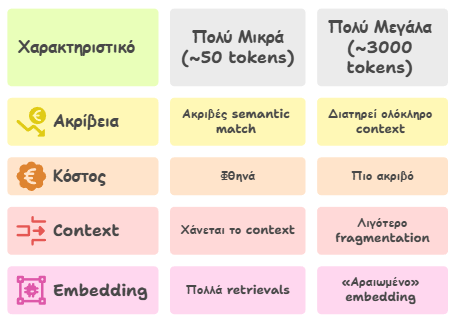

**Γενικός κανόνας:** ξεκίνα με **chunk size 500–1000 tokens** και **overlap 10–20%**, μέτρα, βελτίωσε.

<img src="images/chunking_tradeoff.png" width="100%" style="border-radius:10px;margin:12px 0;"/>

***Εικ. 1.1** — Το δίλημμα του chunking: μικρά chunks = ακριβές match αλλά χάνει context. Μεγάλα = διατηρεί context αλλά το embedding γίνεται «αραιό». Sweet spot: 500–1000 tokens.*

### 1.3.1 Counting tokens

Ένα **token** ≈ 4 χαρακτήρες αγγλικού κειμένου (στα ελληνικά λίγο λιγότερο).

In [19]:
import tiktoken

encoder = tiktoken.encoding_for_model(LLM_MODEL)

def count_tokens(text: str) -> int:
    return len(encoder.encode(text))

samples = [
    "Hello World!",
    "Retrieval-Augmented Generation",
    "RAG is an architectural pattern that ground LLM answer in retrieved documents",
    "AI for Developers is the best bootcamp!",
]

for s in samples:
    print(f"{count_tokens(s)} tokens | {s}")

3 tokens | Hello World!
5 tokens | Retrieval-Augmented Generation
14 tokens | RAG is an architectural pattern that ground LLM answer in retrieved documents
9 tokens | AI for Developers is the best bootcamp!


### 1.3.2 CharacterTextSplitter — απλούστερη μέθοδος

Κόβει σε **σταθερά μήκη χαρακτήρων** σε ένα separator (default `\n\n`).

In [20]:
from langchain_text_splitters import CharacterTextSplitter
import tiktoken

long_text = (
    "Chapter 1 introduces the four fundamental limits of LLMs.\n\n"
    "The first limit is the knowledge cutoff: the model is frozen in time after training.\n\n"
    "The second limit is private data: the model has never seen internal documents.\n\n"
    "The third limit is hallucination: fluent, plausible, and false output."
)

splitter = CharacterTextSplitter(
    separator="\n\n",
    chunk_size = 100,
    chunk_overlap = 0
)

chunks = splitter.split_text(long_text)

total_chunks = len(chunks)

# Tokenizer
encoding = tiktoken.get_encoding("cl100k_base")

for i, c in enumerate(chunks, 1):
    token_count = len(encoder.encode(c))

    print(f"---Chunk {i} of {total_chunks}---")
    print(f"Characters: {len(c)}")
    print(f"Tokens: {token_count}")
    print(c, "\n")

---Chunk 1 of 4---
Characters: 57
Tokens: 13
Chapter 1 introduces the four fundamental limits of LLMs. 

---Chunk 2 of 4---
Characters: 84
Tokens: 17
The first limit is the knowledge cutoff: the model is frozen in time after training. 

---Chunk 3 of 4---
Characters: 78
Tokens: 15
The second limit is private data: the model has never seen internal documents. 

---Chunk 4 of 4---
Characters: 70
Tokens: 15
The third limit is hallucination: fluent, plausible, and false output. 



### 1.3.3 RecursiveCharacterTextSplitter — η default επιλογή

Αυτό είναι το **most-used** splitter. Δοκιμάζει μια λίστα από separators (`["\n\n", "\n", " ", ""]`) με τη σειρά, κρατώντας paragraphs > sentences > words ενωμένα όσο γίνεται.

In [21]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

# Datanous.ai knowledge base content as demo document
tech_doc = (
    "# The RAG Pipeline\n\n"
    "RAG is an architectural pattern, not a new model. It arranges an LLM alongside "
    "an external document collection so answers are grounded in retrieved evidence.\n\n"
    "## Indexing Phase\n\n"
    "The indexing phase runs offline: ingest raw documents, chunk them, embed each chunk "
    "with an embedding model, and store the vectors in a vector database.\n\n"
    "## Query Phase\n\n"
    "The query phase runs online per user request: encode the question, retrieve top-k "
    "similar chunks, inject context into the prompt, and generate a grounded answer."
)

splitter = RecursiveCharacterTextSplitter(
    chunk_size= 120,
    chunk_overlap = 20,
    separators=["\n\n", "\n", " ", ""],
)

chunks = splitter.split_text(tech_doc)

for i, c in enumerate(chunks, 1):
    token_count = len(encoder.encode(c))

    print(f"---Chunk {i} of {len(chunks)}---")
    print(f"Characters: {len(c)}")
    print(f"Tokens: {token_count}")
    print(c, "\n")

---Chunk 1 of 9---
Characters: 18
Tokens: 5
# The RAG Pipeline 

---Chunk 2 of 9---
Characters: 113
Tokens: 24
RAG is an architectural pattern, not a new model. It arranges an LLM alongside an external document collection so 

---Chunk 3 of 9---
Characters: 57
Tokens: 9
collection so answers are grounded in retrieved evidence. 

---Chunk 4 of 9---
Characters: 17
Tokens: 4
## Indexing Phase 

---Chunk 5 of 9---
Characters: 118
Tokens: 23
The indexing phase runs offline: ingest raw documents, chunk them, embed each chunk with an embedding model, and store 

---Chunk 6 of 9---
Characters: 50
Tokens: 11
model, and store the vectors in a vector database. 

---Chunk 7 of 9---
Characters: 14
Tokens: 3
## Query Phase 

---Chunk 8 of 9---
Characters: 117
Tokens: 22
The query phase runs online per user request: encode the question, retrieve top-k similar chunks, inject context into 

---Chunk 9 of 9---
Characters: 63
Tokens: 12
inject context into the prompt, and generate a grounded answer. 



### 1.3.4 Splitting βάσει tokens (πιο ακριβές)

Όταν δουλεύεις με LLMs που έχουν αυστηρό token limit, καλύτερα να μετράς tokens, όχι chars.

In [22]:
# Token-based splitting — chunk_size and chunk_overlap are in tokens, not characters.
# With chunk_overlap=20, the last ~20 tokens of each chunk repeat at the start of the next.
# This prevents information loss at chunk boundaries.
 
splitter_tok = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name="cl100k_base",
    chunk_size=40,      # 40 tokens per chunk (~160 characters)
    chunk_overlap=20,   # 20-token overlap between adjacent chunks
)
chunks = splitter_tok.split_text(tech_doc)
 
# Print each chunk and highlight the overlap with the next chunk
for i, c in enumerate(chunks):
    print(f"--- Chunk {i+1} ({count_tokens(c)} tokens) ---")
    print(c)
    if i < len(chunks) - 1:
        # Find and print the overlapping portion with the next chunk
        words_end   = c.split()[-8:]        # last ~8 words of this chunk
        words_start = chunks[i+1].split()[:8]  # first ~8 words of next chunk
        overlap_words = [w for w in words_end if w in words_start]
        if overlap_words:
            print(f"  [overlap with next chunk: ...{' '.join(overlap_words[:6])}...]")
    print()

--- Chunk 1 (37 tokens) ---
# The RAG Pipeline

RAG is an architectural pattern, not a new model. It arranges an LLM alongside an external document collection so answers are grounded in retrieved evidence.

--- Chunk 2 (38 tokens) ---
## Indexing Phase

The indexing phase runs offline: ingest raw documents, chunk them, embed each chunk with an embedding model, and store the vectors in a vector database.

## Query Phase
  [overlap with next chunk: ...## Query Phase...]

--- Chunk 3 (35 tokens) ---
## Query Phase

The query phase runs online per user request: encode the question, retrieve top-k similar chunks, inject context into the prompt, and generate a grounded answer.



### 1.3.5 Format-aware splitters

Για κώδικα ή markdown, υπάρχουν specialized splitters που σέβονται τη δομή:

In [23]:
from langchain_text_splitters import Language, RecursiveCharacterTextSplitter

python_code = '''
def authenticate(username, password):
    """Επιστρέφει JWT token αν τα credentials είναι σωστά."""
    user = db.find_user(username)
    if user and verify_password(password, user.hash):
        return create_token(user.id)
    return None

class Session:
    def __init__(self, user_id):
        self.user_id = user_id
        self.created_at = now()
    
    def is_expired(self):
        return (now() - self.created_at).hours > 24
'''

py_splitter = RecursiveCharacterTextSplitter.from_language(
    language=Language.PYTHON, chunk_size=120, chunk_overlap=0
)
for i, c in enumerate(py_splitter.split_text(python_code)):
    print(f"--- Code chunk {i+1} ---\n{c}\n")

--- Code chunk 1 ---
def authenticate(username, password):
    """Επιστρέφει JWT token αν τα credentials είναι σωστά."""

--- Code chunk 2 ---
user = db.find_user(username)
    if user and verify_password(password, user.hash):

--- Code chunk 3 ---
return create_token(user.id)
    return None

--- Code chunk 4 ---
class Session:
    def __init__(self, user_id):
        self.user_id = user_id
        self.created_at = now()

--- Code chunk 5 ---
def is_expired(self):
        return (now() - self.created_at).hours > 24



## 1.4 Embeddings — μετρώντας το «νόημα»

Ένα embedding είναι ένα vector (συνήθως 384–3072 διαστάσεις) που αναπαριστά το «νόημα» ενός κειμένου.

**Ιδιότητα κλειδί:** κείμενα με παρόμοιο νόημα → vectors με παρόμοια κατεύθυνση.

Η ομοιότητα μετριέται συνήθως με **cosine similarity**:

$$\cos(\theta) = \frac{\mathbf{a} \cdot \mathbf{b}}{||\mathbf{a}||\,||\mathbf{b}||} \in [-1, 1]$$

* `1` → πανομοιότυπο νόημα
* `0` → άσχετα
* `-1` → αντίθετα (σπάνιο σε embeddings)

<img src="images/embedding_space.png" width="50%" style="border-radius:10px;margin:12px 0;"/>

***Εικ. 1.2** — Ο χώρος των embeddings: κείμενα παρόμοιου νοήματος σχηματίζουν clusters. Το cosine similarity μετρά τη γωνία μεταξύ vectors.*

In [24]:
from langchain_openai import OpenAIEmbeddings
import numpy as np

embedder = OpenAIEmbeddings(model=EMBED_MODEL)

def cosine(a, b):
    a, b = np.array(a), np.array(b)
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

query = "How does Datanous Search handle hybrid retrieval?"
candidates = [
    "Datanous Search combines BM25 and dense embeddings with Reciprocal Rank Fusion.",  # relevant
    "Datanous.ai was founded in 2021 and is headquartered in Athens, Greece.",           # same domain, off-topic
    "The most popular spice in Indonesian cuisine is cloves.",                            # completely unrelated
]

q_vec  = embedder.embed_query(query)
c_vecs = embedder.embed_documents(candidates)

print(f"Query: {query}\n")
for text, vec in zip(candidates, c_vecs):
    sim = cosine(q_vec, vec)
    bar = "#" * int(sim * 40)
    print(f"  {sim:.3f} |{bar}")
    print(f"         {text[:80]}\n")


Query: How does Datanous Search handle hybrid retrieval?

  0.671 |##########################
         Datanous Search combines BM25 and dense embeddings with Reciprocal Rank Fusion.

  0.315 |############
         Datanous.ai was founded in 2021 and is headquartered in Athens, Greece.

  0.016 |
         The most popular spice in Indonesian cuisine is cloves.



Παρατήρησε ότι οι τιμές είναι **όλες θετικές** (κοντά στο 0.3–0.7) επειδή οι σύγχρονες embeddings τείνουν να ζουν σε έναν στενό κώνο. Αυτό που μετράει είναι η **σχετική** σειρά.

### Embedding models — τι να επιλέξεις

| Model | Διάσταση | Κόστος | Σημείωση |
|---|---|---|---|
| `text-embedding-3-small` | 1536 (configurable) | $$ | Default — εξαιρετικός λόγος cost/quality |
| `text-embedding-3-large` | 3072 (configurable) | $$$$ | Καλύτερη ποιότητα, x6 ακριβότερο |
| `all-MiniLM-L6-v2` (HF) | 384 | δωρεάν (local) | Καλό για prototyping χωρίς κόστος |
| `cohere/embed-multilingual-v3.0` | 1024 | $$ | Εξαιρετικό για multilingual |
| `BGE-large-en-v1.5` (HF) | 1024 | δωρεάν (local) | Top-tier ανοιχτό μοντέλο |

💡 **Tip:** Μπορείς να κατεβάσεις τη διάσταση του `text-embedding-3-small` (πχ σε 512) με `dimensions=512` παράμετρο — γλιτώνεις χώρο/κόστος vector store με μικρή απώλεια ποιότητας.

## 1.5 Vector Stores

Μια **vector database** αποθηκεύει embeddings + κάνει γρήγορο **k-nearest neighbour** search.

| Vector store | Persistence | Καλύτερο για |
|---|---|---|
| **Chroma** | Local (file ή in-memory) | Prototypes, μικρά datasets |
| **FAISS** | Local | Πολύ γρήγορο in-memory search |
| **Pinecone** | Cloud (managed) | Production, scale, hassle-free |
| **Weaviate** / **Qdrant** | Self-hosted ή cloud | Production με filtering και multi-tenancy |
| **pgvector** (PostgreSQL) | Local/cloud DB | Όταν θες να μείνεις σε relational DB |

### 1.5.1 Chroma (in-memory)

In [25]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document

embedder = OpenAIEmbeddings(model=EMBED_MODEL)

# Datanous.ai knowledge base — defined once, reused in cells below
datanous_docs = [
    Document(page_content="Datanous.ai is an AI services company founded in 2021 in Athens, Greece, with offices in London and Amsterdam.", metadata={"source": "datanous_overview.txt", "product": "company"}),
    Document(page_content="Datanous Insight is a RAG-powered knowledge management platform that indexes enterprise documents and answers queries with source citations.", metadata={"source": "datanous_products.txt", "product": "Insight"}),
    Document(page_content="Datanous Insight Starter costs 50 USD per month (10,000 pages). Professional costs 350 USD per month (100,000 pages). Enterprise is unlimited with a 99.9 percent uptime SLA.", metadata={"source": "datanous_products.txt", "product": "Insight", "section": "pricing"}),
    Document(page_content="Datanous Search is a hybrid retrieval API combining BM25 and dense semantic embeddings with Reciprocal Rank Fusion. Latency under 200 ms over one million chunks.", metadata={"source": "datanous_products.txt", "product": "Search"}),
    Document(page_content="Datanous Guard enforces factual grounding, detects prompt injection, redacts PII, and applies tenant isolation via tenant_id filtering.", metadata={"source": "datanous_products.txt", "product": "Guard"}),
    Document(page_content="Datanous Embed supports text-embedding-3-small (1536 dims) and text-embedding-3-large (3072 dims) with Redis caching. Cache hit rate on enterprise corpora exceeds 60 percent.", metadata={"source": "datanous_products.txt", "product": "Embed"}),
    Document(page_content="Datanous.ai serves clients in banking, legal, healthcare, and media. A law firm reduced search time from 2.5 hours to 8 minutes with a 91 percent faithfulness score.", metadata={"source": "datanous_case_studies.txt", "section": "results"}),
    Document(page_content="A retail bank using Datanous Insight Enterprise reduced regulatory query resolution from 4 days to under 30 seconds over a corpus of 12,000 regulatory pages.", metadata={"source": "datanous_case_studies.txt", "industry": "banking"}),
]

vectorstore = Chroma.from_documents(datanous_docs, embedding=embedder)
print(f"Vector store created with {vectorstore._collection.count()} documents")

query = "What is the price of the Professional plan?"

results = vectorstore.similarity_search_with_score(query, k=3)

print("\nTop results:")
for r, score in results:
    print(
        f"  score={score:.4f} "
        f"[{r.metadata.get('product','?')}] "
        f"{r.page_content[:100]}..."
    )

Vector store created with 8 documents

Top results:
  score=0.9710 [Insight] Datanous Insight Starter costs 50 USD per month (10,000 pages). Professional costs 350 USD per month...
  score=1.7395 [Embed] Datanous Embed supports text-embedding-3-small (1536 dims) and text-embedding-3-large (3072 dims) wi...
  score=1.7474 [?] Datanous.ai serves clients in banking, legal, healthcare, and media. A law firm reduced search time ...


### 1.5.2 Με score (πόσο σχετικό είναι;)

In [26]:
# Similarity search with relevance scores (0.0 = unrelated, 1.0 = identical)
results_with_scores = vectorstore.similarity_search_with_relevance_scores(
    "What does Datanous Guard protect against?", k=3
)

print("Results with cosine similarity scores:")
for doc, score in results_with_scores:
    print(f"  [{score:.3f}] {doc.page_content[:90]}")

MIN_SCORE = 0.6
relevant = [(d, s) for d, s in results_with_scores if s >= MIN_SCORE]
print(f"\nAbove threshold ({MIN_SCORE}): {len(relevant)}/{len(results_with_scores)} results")


Results with cosine similarity scores:
  [0.567] Datanous Guard enforces factual grounding, detects prompt injection, redacts PII, and appl
  [0.202] Datanous Insight is a RAG-powered knowledge management platform that indexes enterprise do
  [0.164] Datanous.ai is an AI services company founded in 2021 in Athens, Greece, with offices in L

Above threshold (0.6): 0/3 results


### 1.5.3 Filtering με metadata

Αυτό είναι **πανίσχυρο** feature: μπορείς να περιορίσεις την αναζήτηση σε ένα subset (πχ μόνο ένα product).

In [27]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document

embedder = OpenAIEmbeddings(model=EMBED_MODEL)

# Datanous.ai documents tagged by product
tagged_docs = [
    Document(page_content="Datanous.ai is an AI services company founded in 2021 in Athens, Greece, with offices in London and Amsterdam.", metadata={"source": "datanous_overview.txt", "product": "company"}),
    Document(page_content="Datanous Insight is a RAG-powered knowledge management platform that indexes enterprise documents and answers queries with source citations.", metadata={"source": "datanous_products.txt", "product": "Insight"}),
    Document(page_content="Datanous Insight Starter costs 50 USD per month (10,000 pages). Professional costs 350 USD per month (100,000 pages). Enterprise is unlimited with a 99.9 percent uptime SLA.", metadata={"source": "datanous_products.txt", "product": "Insight", "section": "pricing"}),
    Document(page_content="Datanous Search is a hybrid retrieval API combining BM25 and dense semantic embeddings with Reciprocal Rank Fusion. Latency under 200 ms over one million chunks.", metadata={"source": "datanous_products.txt", "product": "Search"}),
    Document(page_content="Datanous Guard enforces factual grounding, detects prompt injection, redacts PII, and applies tenant isolation via tenant_id filtering.", metadata={"source": "datanous_products.txt", "product": "Guard"}),
    Document(page_content="Datanous Embed supports text-embedding-3-small (1536 dims) and text-embedding-3-large (3072 dims) with Redis caching. Cache hit rate on enterprise corpora exceeds 60 percent.", metadata={"source": "datanous_products.txt", "product": "Embed"}),
    Document(page_content="Datanous.ai serves clients in banking, legal, healthcare, and media. A law firm reduced search time from 2.5 hours to 8 minutes with a 91 percent faithfulness score.", metadata={"source": "datanous_case_studies.txt", "section": "results"}),
    Document(page_content="A retail bank using Datanous Insight Enterprise reduced regulatory query resolution from 4 days to under 30 seconds over a corpus of 12,000 regulatory pages.", metadata={"source": "datanous_case_studies.txt", "industry": "banking"}),
    Document(page_content="All Datanous.ai deployments encrypt data in transit with TLS 1.3 and at rest with AES-256. The company is GDPR-compliant.", metadata={"source": "datanous_faq.txt", "topic": "privacy"}),
    Document(page_content="Datanous.ai is a certified partner of OpenAI, Anthropic, Pinecone, and Weaviate, building on LangChain, LangGraph, and LangSmith.", metadata={"source": "datanous_overview.txt", "section": "partners"}),
]

vs_tagged = Chroma.from_documents(tagged_docs, embedding=embedder)

# Filter to Datanous Insight documents only
results = vs_tagged.similarity_search(
    "What are the pricing tiers?",
    k=3,
    filter={"product": "Insight"}, # Metadata filtering
)
print("Results filtered to Datanous Insight:")
for r in results:
    print(f"  [{r.metadata.get('product','?')} / {r.metadata.get('section','?')}] {r.page_content[:100]}...")


Results filtered to Datanous Insight:
  [Insight / pricing] Datanous Insight Starter costs 50 USD per month (10,000 pages). Professional costs 350 USD per month...
  [Insight / pricing] Datanous Insight Starter costs 50 USD per month (10,000 pages). Professional costs 350 USD per month...
  [Insight / ?] Datanous Insight is a RAG-powered knowledge management platform that indexes enterprise documents an...


### 1.5.4 Persistence — αποθήκευση σε δίσκο

In [28]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

embedder = OpenAIEmbeddings(model=EMBED_MODEL)

# Persist the Datanous.ai knowledge base to disk
persistent_store = Chroma.from_documents(
    datanous_docs,
    embedding=embedder,
    persist_directory="./datanous_chroma_db", # persistence memory
)
print(f"Saved {persistent_store._collection.count()} documents to ./datanous_chroma_db")

# Reload from disk — no re-embedding needed
loaded_store = Chroma(
    persist_directory="./datanous_chroma_db",
    embedding_function=embedder,
)
print(f"Reloaded {loaded_store._collection.count()} documents from disk")

# Verify retrieval still works
results = loaded_store.similarity_search("Tell me about Datanous Embed", k=2)
for r in results:
    print(f"  [{r.metadata.get('product','?')}] {r.page_content[:90]}")


Saved 8 documents to ./datanous_chroma_db
Reloaded 8 documents from disk
  [Embed] Datanous Embed supports text-embedding-3-small (1536 dims) and text-embedding-3-large (307
  [Search] Datanous Search is a hybrid retrieval API combining BM25 and dense semantic embeddings wit


### 1.5.5 FAISS — όταν θες ταχύτητα

1. Το query μετατρέπεται σε embedding.
2. To FAISS ψάχνει στο index.faiss αρχείο τα πιο κοντινά διανύσματα.
3. Επιστρέφει ids.
4. H LangChain κοιτάει στο index.pkl ποιά chunks αντιστοιχούν στα παραπάνω ids.
5. Παίρνουμε πίσω τα σχετικά κείμενα. 

In [29]:
try:
    from langchain_community.vectorstores import FAISS
    from langchain_openai import OpenAIEmbeddings
    from langchain_core.documents import Document

    embedder = OpenAIEmbeddings(model=EMBED_MODEL)

    faiss_docs = [
        Document(page_content="Datanous.ai is an AI services company founded in 2021 in Athens, Greece, with offices in London and Amsterdam.", metadata={"source": "datanous_overview.txt", "product": "company"}),
        Document(page_content="Datanous Insight is a RAG-powered knowledge management platform that indexes enterprise documents and answers queries with source citations.", metadata={"source": "datanous_products.txt", "product": "Insight"}),
        Document(page_content="Datanous Insight Starter costs 50 USD per month (10,000 pages). Professional costs 350 USD per month (100,000 pages). Enterprise is unlimited with a 99.9 percent uptime SLA.", metadata={"source": "datanous_products.txt", "product": "Insight", "section": "pricing"}),
        Document(page_content="Datanous Search is a hybrid retrieval API combining BM25 and dense semantic embeddings with Reciprocal Rank Fusion. Latency under 200 ms over one million chunks.", metadata={"source": "datanous_products.txt", "product": "Search"}),
        Document(page_content="Datanous Guard enforces factual grounding, detects prompt injection, redacts PII, and applies tenant isolation via tenant_id filtering.", metadata={"source": "datanous_products.txt", "product": "Guard"}),
        Document(page_content="Datanous Embed supports text-embedding-3-small (1536 dims) and text-embedding-3-large (3072 dims) with Redis caching. Cache hit rate on enterprise corpora exceeds 60 percent.", metadata={"source": "datanous_products.txt", "product": "Embed"}),
    ]

    faiss_store = FAISS.from_documents(faiss_docs, embedding=embedder)
    results = faiss_store.similarity_search("How does Datanous Search work?", k=2)
    print("FAISS results:")
    for r in results:
        print(f"  [{r.metadata.get('product','?')}] {r.page_content[:90]}")

    faiss_store.save_local("faiss_datanous_index")
    reloaded = FAISS.load_local("faiss_datanous_index", embedder, allow_dangerous_deserialization=True)
    print(f"\nReloaded FAISS store with {reloaded.index.ntotal} vectors")
except ImportError:
    print("faiss-cpu not installed. Run: pip install faiss-cpu")


FAISS results:
  [Search] Datanous Search is a hybrid retrieval API combining BM25 and dense semantic embeddings wit
  [Insight] Datanous Insight is a RAG-powered knowledge management platform that indexes enterprise do

Reloaded FAISS store with 6 vectors


## 1.6 MMR — διαφορετικότητα στα αποτελέσματα

Με απλό similarity search μπορεί να πάρεις 3 σχεδόν **πανομοιότυπα** docs — χάνεις διαφορετικές οπτικές γωνίες.

Το **Maximal Marginal Relevance (MMR)** ισορροπεί:

* **Σχετικότητα** με το query
* **Διαφορετικότητα** μεταξύ των επιστρεφόμενων docs

$$\text{MMR} = \arg\max_{d_i \in R \setminus S} \Big[\,\lambda \cdot \text{sim}(d_i, q) - (1-\lambda) \max_{d_j \in S} \text{sim}(d_i, d_j)\Big]$$

In [30]:
# MMR balances relevance (vs the query) with diversity (vs already-selected results).
# fetch_k: wider candidate set; k: final output; lambda_mult: 1=pure relevance, 0=max diversity

from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document

embedder = OpenAIEmbeddings(model=EMBED_MODEL)

# Corpus with near-duplicate Datanous Insight pricing entries to show MMR effect
mmr_docs = [
    Document(page_content="Datanous Insight Starter: 50 USD per month, up to 10,000 document pages."),
    Document(page_content="Datanous Insight Starter plan costs 50 USD/month and covers 10,000 pages with community support."),
    Document(page_content="The Starter tier of Datanous Insight is priced at 50 USD monthly for single-tenant deployments."),
    Document(page_content="Datanous Insight Professional: 350 USD per month, up to 100,000 pages, multi-tenant access control."),
    Document(page_content="Datanous Search delivers hybrid retrieval with BM25 and dense embeddings via RRF."),
    Document(page_content="Datanous Guard performs factual grounding, PII redaction, and tenant isolation."),
]

mmr_store = Chroma.from_documents(mmr_docs, embedding=embedder)

std = mmr_store.similarity_search("Datanous Insight pricing", k=3)
print("Standard search (may return near-duplicates):")
for r in std:
    print(f"  {r.page_content[:80]}")

diverse = mmr_store.max_marginal_relevance_search(
    "Datanous Insight pricing", k=3, fetch_k=6, lambda_mult=0.5
)
print("\nMMR search (diverse results):")
for r in diverse:
    print(f"  {r.page_content[:80]}")


Standard search (may return near-duplicates):
  Datanous Insight Starter costs 50 USD per month (10,000 pages). Professional cos
  Datanous Insight Starter costs 50 USD per month (10,000 pages). Professional cos
  Datanous Insight Professional: 350 USD per month, up to 100,000 pages, multi-ten

MMR search (diverse results):
  Datanous Insight Starter costs 50 USD per month (10,000 pages). Professional cos
  Datanous Insight Professional: 350 USD per month, up to 100,000 pages, multi-ten
  The Starter tier of Datanous Insight is priced at 50 USD monthly for single-tena


## 1.7 Retriever interface

Όλες οι παραπάνω μέθοδοι μπορούν να εκτεθούν ως **retriever** — ένα standardized interface που τσιμπάει σωστά στις LCEL chains.

```python
Args:
            **kwargs: Keyword arguments to pass to the search function.

                Can include:

                * `search_type`: Defines the type of search that the Retriever should
                    perform. Can be `'similarity'` (default), `'mmr'`, or
                    `'similarity_score_threshold'`.
                * `search_kwargs`: Keyword arguments to pass to the search function.

                    Can include things like:

                    * `k`: Amount of documents to return (Default: `4`)
                    * `score_threshold`: Minimum relevance threshold
                        for `similarity_score_threshold`
                    * `fetch_k`: Amount of documents to pass to MMR algorithm
                        (Default: `20`)
                    * `lambda_mult`: Diversity of results returned by MMR;
                        `1` for minimum diversity and 0 for maximum. (Default: `0.5`)
                    * `filter`: Filter by document metadata
```

In [18]:
# as_retriever() exposes a standardised LangChain Retriever interface.
# It plugs directly into LCEL chains: retriever | prompt | llm | parser

from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document

embedder = OpenAIEmbeddings(model=EMBED_MODEL)

ret_docs = [
    Document(page_content="Datanous.ai is an AI services company founded in 2021 in Athens, Greece, with offices in London and Amsterdam.", metadata={"source": "datanous_overview.txt", "product": "company"}),
    Document(page_content="Datanous Insight is a RAG-powered knowledge management platform that indexes enterprise documents and answers queries with source citations.", metadata={"source": "datanous_products.txt", "product": "Insight"}),
    Document(page_content="Datanous Insight Starter costs 50 USD per month (10,000 pages). Professional costs 350 USD per month (100,000 pages). Enterprise is unlimited with a 99.9 percent uptime SLA.", metadata={"source": "datanous_products.txt", "product": "Insight", "section": "pricing"}),
    Document(page_content="Datanous Search is a hybrid retrieval API combining BM25 and dense semantic embeddings with Reciprocal Rank Fusion. Latency under 200 ms over one million chunks.", metadata={"source": "datanous_products.txt", "product": "Search"}),
    Document(page_content="Datanous Guard enforces factual grounding, detects prompt injection, redacts PII, and applies tenant isolation via tenant_id filtering.", metadata={"source": "datanous_products.txt", "product": "Guard"}),
    Document(page_content="Datanous Embed supports text-embedding-3-small (1536 dims) and text-embedding-3-large (3072 dims) with Redis caching. Cache hit rate on enterprise corpora exceeds 60 percent.", metadata={"source": "datanous_products.txt", "product": "Embed"}),
    Document(page_content="Datanous.ai serves clients in banking, legal, healthcare, and media. A law firm reduced search time from 2.5 hours to 8 minutes with a 91 percent faithfulness score.", metadata={"source": "datanous_case_studies.txt", "section": "results"}),
    Document(page_content="A retail bank using Datanous Insight Enterprise reduced regulatory query resolution from 4 days to under 30 seconds over a corpus of 12,000 regulatory pages.", metadata={"source": "datanous_case_studies.txt", "industry": "banking"}),
]

vs = Chroma.from_documents(ret_docs, embedding=embedder)

retriever = vs.as_retriever(search_kwargs={"k": 2})
results = retriever.invoke("What is the uptime SLA for Datanous Insight Enterprise?")
print("Retriever results (k=2):")
for r in results:
    print(f"  [{r.metadata.get('product','?')}] {r.page_content[:100]}")

mmr_retriever = vs.as_retriever(
    search_type="mmr",
    search_kwargs={"k": 2, "fetch_k": 6, "lambda_mult": 0.5},
)
print("\nMMR Retriever results:")
for r in mmr_retriever.invoke("What products does Datanous.ai offer?"):
    print(f"  [{r.metadata.get('product','?')}] {r.page_content[:100]}")


Retriever results (k=2):
  [Insight] Datanous Insight Starter costs 50 USD per month (10,000 pages). Professional costs 350 USD per month
  [Insight] Datanous Insight Starter costs 50 USD per month (10,000 pages). Professional costs 350 USD per month

MMR Retriever results:
  [company] Datanous.ai is an AI services company founded in 2021 in Athens, Greece, with offices in London and 
  [?] Datanous.ai is a certified partner of OpenAI, Anthropic, Pinecone, and Weaviate, building on LangCha


## 1.8 End-to-end: indexing pipeline

Ας τα βάλουμε όλα μαζί για να δημιουργήσουμε ένα πραγματικό index από τον φάκελο `srag_textbook/`.

In [19]:
# End-to-end indexing pipeline over the datanous_kb/ directory

# 1. Load
loader = DirectoryLoader(
    str(kb_dir), glob="*.txt",
    loader_cls=TextLoader, loader_kwargs={"encoding": "utf-8"},
)
raw_docs = loader.load()
print(f"Step 1 - Loaded {len(raw_docs)} document(s) from datanous_kb/")

# 2. Split
splitter = RecursiveCharacterTextSplitter.from_tiktoken_encoder(
    encoding_name="cl100k_base", chunk_size=200, chunk_overlap=30,
)
chunked_docs = splitter.split_documents(raw_docs)
print(f"Step 2 - Split into {len(chunked_docs)} chunks")

# 3. Enrich metadata
for d in chunked_docs:
    d.metadata["source_file"] = Path(d.metadata["source"]).stem

# 4. Embed and store
index = Chroma.from_documents(chunked_docs, embedding=embedder)
print(f"Step 3 - Indexed {index._collection.count()} chunks in Chroma")

# 5. Query
retriever = index.as_retriever(search_kwargs={"k": 2})
for r in retriever.invoke("What does Datanous Guard protect against?"):
    print(f"  [{r.metadata.get('source_file','?')}] {r.page_content[:110]}...")


Step 1 - Loaded 6 document(s) from datanous_kb/
Step 2 - Split into 15 chunks
Step 3 - Indexed 47 chunks in Chroma
  [datanous_guard] Datanous Guard is an AI governance middleware. It performs four checks: (1) factual grounding, (2) prompt inje...
  [?] Datanous Guard enforces factual grounding, detects prompt injection, redacts PII, and applies tenant isolation...


## 1.9 Άσκηση

**Άσκηση:** Φτιάξε μια συνάρτηση `build_index(folder, chunk_size, chunk_overlap)` που:

1. Φορτώνει όλα τα `.txt` από έναν φάκελο
2. Τα κόβει σε chunks του `chunk_size` (token-based)
3. Προσθέτει metadata `source_file` με το όνομα
4. Επιστρέφει ένα Chroma vector store

In [ ]:
# Exercise: Build a function that creates a Chroma vector store from a folder.
#
# def build_datanous_index(folder: str, chunk_size: int = 200, chunk_overlap: int = 30):
#     1. Load all .txt files from the folder using DirectoryLoader
#     2. Split with RecursiveCharacterTextSplitter.from_tiktoken_encoder
#     3. Add metadata["source_file"] = stem of the source filename
#     4. Return a Chroma vector store built from the chunks
#
# Test it with: build_datanous_index("datanous_kb")
# Then query: "What is the uptime SLA for Datanous Insight Enterprise?"

# Your solution here:


In [ ]:
# Sanity check: verify the datanous_kb/ directory is ready for indexing
from pathlib import Path

kb_dir = Path("datanous_kb")
if not kb_dir.exists():
    print("datanous_kb/ not found. Run cell 1.2.3 first to create it.")
else:
    files = list(kb_dir.glob("*.txt"))
    total_chars = sum(len(f.read_text(encoding="utf-8")) for f in files)
    print(f"datanous_kb/ contains {len(files)} file(s), {total_chars:,} total characters")
    for f in files:
        text = f.read_text(encoding="utf-8")
        print(f"  {f.name}: {len(text):,} chars")
    print("\nReady to index with DirectoryLoader and ChromaDB.")


## 📋 Συμπεράσματα

| # | Έννοια | Συνοπτικά |
|---|---|---|
| 1 | `Document` | `page_content` + `metadata` — η μονάδα του LangChain |
| 2 | Loaders | Από οποιαδήποτε πηγή σε `Document` (PDF, web, Notion...) |
| 3 | Tokens | Μετράμε με `tiktoken`, όχι characters |
| 4 | Chunking trade-off | Μικρά → ακριβές match αλλά χάνει context, μεγάλα → αντίθετα |
| 5 | RecursiveCharacterTextSplitter | Default επιλογή — σέβεται paragraphs/sentences |
| 6 | Format-aware splitters | Code, markdown, HTML έχουν δικά τους |
| 7 | Embedding | Vector που εκφράζει το νόημα ενός κειμένου |
| 8 | Cosine similarity | $\cos(\theta) \in [-1,1]$ — βασική μετρική |
| 9 | Embedding models | `text-embedding-3-small` = solid default |
| 10 | Vector stores | Chroma (local), FAISS (γρήγορο), Pinecone (managed) |
| 11 | Metadata filters | Περιορισμός search σε subset — πολύ ισχυρό |
| 12 | MMR | Διαφοροποίηση αποτελεσμάτων (relevance vs diversity) |
| 13 | Retriever interface | Standardized API που τσιμπάει στις LCEL chains |
| 14 | Επόμενο βήμα | Notebook 02 — Retrieval & Generation σε βάθος |